# Run the full workflow

In [1]:
import datetime

from st.dto.data import PriceDataDTO, ReturnsDTO, CorrelationDTO
from st.dto.volatility import StandardVolatilityDTO, EWMAVolatilityDTO, RobustVolatilityDTO, \
    VolatilityStandardizationDTO, VolatilityDTO, SimpleVolatilityForecastDTO, EWMAVolatilityForecastDTO
from st.plotter import PriceDataPlotter, ReturnsPlotter, VolatilityPlotter  # noqa
from st.dto.strategy import EWMACStrategyDTO

## Price Data, Returns, Correlation Matrix---

In [2]:
# load price data
tickers = ["AAPL", "GOOGL", "AMZN", "MSFT"]
price_datas = [PriceDataDTO(ticker=tkr, start_date=datetime.datetime(year=2023, month=1, day=1)) for tkr in tickers]

# calculate returns
returns = [ReturnsDTO(price_data=pdata) for pdata in price_datas]

# calculate correlations
correlations = CorrelationDTO(price_datas=price_datas)

In [3]:
for pdata in price_datas: print(pdata)
for rt in returns: print(rt)
print(correlations)
correlations.correlation_matrix

PriceData(ticker=AAPL, start_date=2023-01-01 00:00:00, end_date=2025-12-18, interval=1d, shape=(743, 6))
PriceData(ticker=GOOGL, start_date=2023-01-01 00:00:00, end_date=2025-12-18, interval=1d, shape=(743, 6))
PriceData(ticker=AMZN, start_date=2023-01-01 00:00:00, end_date=2025-12-18, interval=1d, shape=(743, 6))
PriceData(ticker=MSFT, start_date=2023-01-01 00:00:00, end_date=2025-12-18, interval=1d, shape=(743, 6))
Returns(ticker=AAPL, return_type=log, shape=(743,), skew=0.5003)
Returns(ticker=GOOGL, return_type=log, shape=(743,), skew=-0.0663)
Returns(ticker=AMZN, return_type=log, shape=(743,), skew=0.0732)
Returns(ticker=MSFT, return_type=log, shape=(743,), skew=0.3368)
Correlation(tickers=['AAPL', 'GOOGL', 'AMZN', 'MSFT'], total_observations=743)


,AAPL,GOOGL,AMZN,MSFT
AAPL,1.000000,0.459624,0.466263,0.486755
GOOGL,0.459624,1.000000,0.561275,0.491552
AMZN,0.466263,0.561275,1.000000,0.607027
MSFT,0.486755,0.491552,0.607027,1.000000


## Plotter for PriceData
---

In [4]:
plotter = PriceDataPlotter()
for pdata in price_datas:
    plotter.add(pdata)

print(plotter)
plotter.show()

PriceDataPlotter: title=Price Data Visualization, price_data=dict_keys(['AAPL', 'GOOGL', 'AMZN', 'MSFT'])


## Plotter for returns
---

In [5]:
plotter = ReturnsPlotter()
for rt in returns:
    print(rt)
    plotter.add(rt)
print(plotter)
plotter.show(plot_type="both", width=900, height=600)

Returns(ticker=AAPL, return_type=log, shape=(743,), skew=0.5003)
Returns(ticker=GOOGL, return_type=log, shape=(743,), skew=-0.0663)
Returns(ticker=AMZN, return_type=log, shape=(743,), skew=0.0732)
Returns(ticker=MSFT, return_type=log, shape=(743,), skew=0.3368)
ReturnsPlotter(tickers=['AAPL', 'GOOGL', 'AMZN', 'MSFT'])


In [6]:
plotter.show_distribution()

In [7]:
plotter.show_skew_comparison()

## Volatility

- all the volatilises are similar.
- EWMA has sudden peaks (undesirable)
- Robust gives the lowest values most of the time. (undesirable)
- Standard seems a good one to use for volatility standardization.
---

In [8]:
vols_classes = [StandardVolatilityDTO, EWMAVolatilityDTO, RobustVolatilityDTO]
vols_data: dict[str, list[VolatilityDTO]] = {}
for rt in returns:
    tkr = rt.price_data.ticker
    vols_data[tkr] = [vc(returns=rt) for vc in vols_classes]
    plotter = VolatilityPlotter()
    [plotter.add(i, tkr + i.__class__.__name__) for i in vols_data[tkr]]
    plotter.show()
vols_data

{'AAPL': [StandardVolatilityDTO(ticker=AAPL, shape=(743,)),
  EWMAVolatilityDTO(ticker=AAPL, shape=(743,)),
  RobustVolatilityDTO(ticker=AAPL, shape=(743,))],
 'GOOGL': [StandardVolatilityDTO(ticker=GOOGL, shape=(743,)),
  EWMAVolatilityDTO(ticker=GOOGL, shape=(743,)),
  RobustVolatilityDTO(ticker=GOOGL, shape=(743,))],
 'AMZN': [StandardVolatilityDTO(ticker=AMZN, shape=(743,)),
  EWMAVolatilityDTO(ticker=AMZN, shape=(743,)),
  RobustVolatilityDTO(ticker=AMZN, shape=(743,))],
 'MSFT': [StandardVolatilityDTO(ticker=MSFT, shape=(743,)),
  EWMAVolatilityDTO(ticker=MSFT, shape=(743,)),
  RobustVolatilityDTO(ticker=MSFT, shape=(743,))]}

## Volatility Standardization
---

In [9]:
# load price data
tickers = ["AAPL", "GOOGL", "AMZN", "MSFT"]
price_datas = [PriceDataDTO(ticker=tkr, start_date=datetime.datetime(year=2023, month=1, day=1)) for tkr in tickers]

print("Non Standardized Returns")
for rt in returns:
    print(rt)

# normal returns
rts = [ReturnsDTO(price_data=pdata) for pdata in price_datas]
rt_plotter = ReturnsPlotter()
for rt in rts:
    rt_plotter.add(rt)
rt_plotter.show()

print("Standardized Returns")

# volatility standardization
vol_st = [VolatilityStandardizationDTO(price_data=pdata) for pdata in price_datas]
standard_rts = [i.returns for i in vol_st]

plotter = VolatilityPlotter()
for v in vol_st:
    plotter.add(v.volatility)
plotter.show()

# plotting
plotter = ReturnsPlotter()
for rt in standard_rts:
    plotter.add(rt)

# for pdata in price_datas:
#     plotter.add(pdata)

plotter.show()

Non Standardized Returns
Returns(ticker=AAPL, return_type=log, shape=(743,), skew=0.5003)
Returns(ticker=GOOGL, return_type=log, shape=(743,), skew=-0.0663)
Returns(ticker=AMZN, return_type=log, shape=(743,), skew=0.0732)
Returns(ticker=MSFT, return_type=log, shape=(743,), skew=0.3368)


Standardized Returns


## Volatility Forecasts
---

In [10]:
for tkr, v in vols_data.items():
    for vv in v:
        print(tkr, SimpleVolatilityForecastDTO(volatility=vv, method="last"))
    print()

AAPL SimpleVolatilityForecastDTO(volatility=StandardVolatilityDTO(ticker=AAPL, shape=(743,)), forecast=0.8854)
AAPL SimpleVolatilityForecastDTO(volatility=EWMAVolatilityDTO(ticker=AAPL, shape=(743,)), forecast=1.0226)
AAPL SimpleVolatilityForecastDTO(volatility=RobustVolatilityDTO(ticker=AAPL, shape=(743,)), forecast=0.6609)

GOOGL SimpleVolatilityForecastDTO(volatility=StandardVolatilityDTO(ticker=GOOGL, shape=(743,)), forecast=2.1259)
GOOGL SimpleVolatilityForecastDTO(volatility=EWMAVolatilityDTO(ticker=GOOGL, shape=(743,)), forecast=2.0002)
GOOGL SimpleVolatilityForecastDTO(volatility=RobustVolatilityDTO(ticker=GOOGL, shape=(743,)), forecast=1.7615)

AMZN SimpleVolatilityForecastDTO(volatility=StandardVolatilityDTO(ticker=AMZN, shape=(743,)), forecast=2.3586)
AMZN SimpleVolatilityForecastDTO(volatility=EWMAVolatilityDTO(ticker=AMZN, shape=(743,)), forecast=1.7843)
AMZN SimpleVolatilityForecastDTO(volatility=RobustVolatilityDTO(ticker=AMZN, shape=(743,)), forecast=2.0096)

MSFT Simpl

## Forecasts
---

In [11]:
ewma_strat = [EWMACStrategyDTO(price_data=pdata) for pdata in price_datas]

<Axes: >

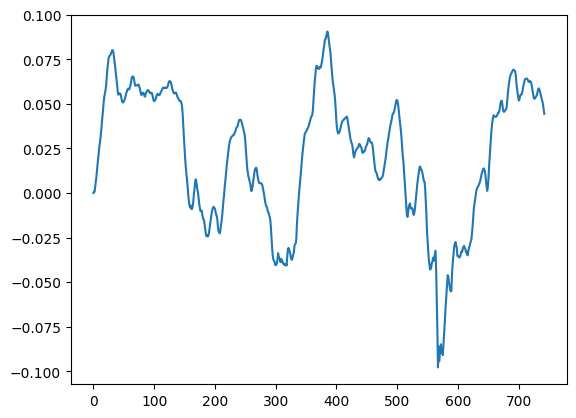

In [13]:
ewma_strat[0].forecasts_raw.plot()

<Axes: >

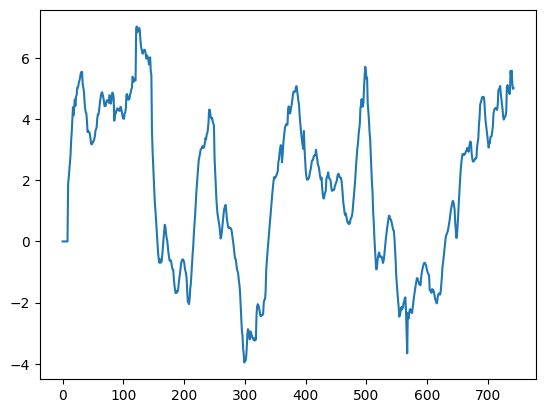

In [14]:
ewma_strat[0].forecasts_vol_normalized.plot()

<Axes: >

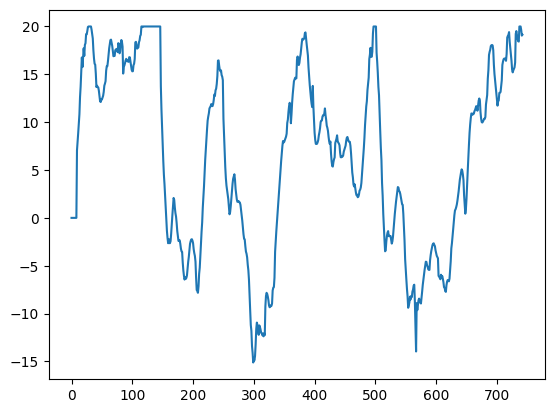

In [15]:
ewma_strat[0].forecasts_scaled.plot()